✅ Structure validée ! 38 classes détectées dans le dossier 'color'.


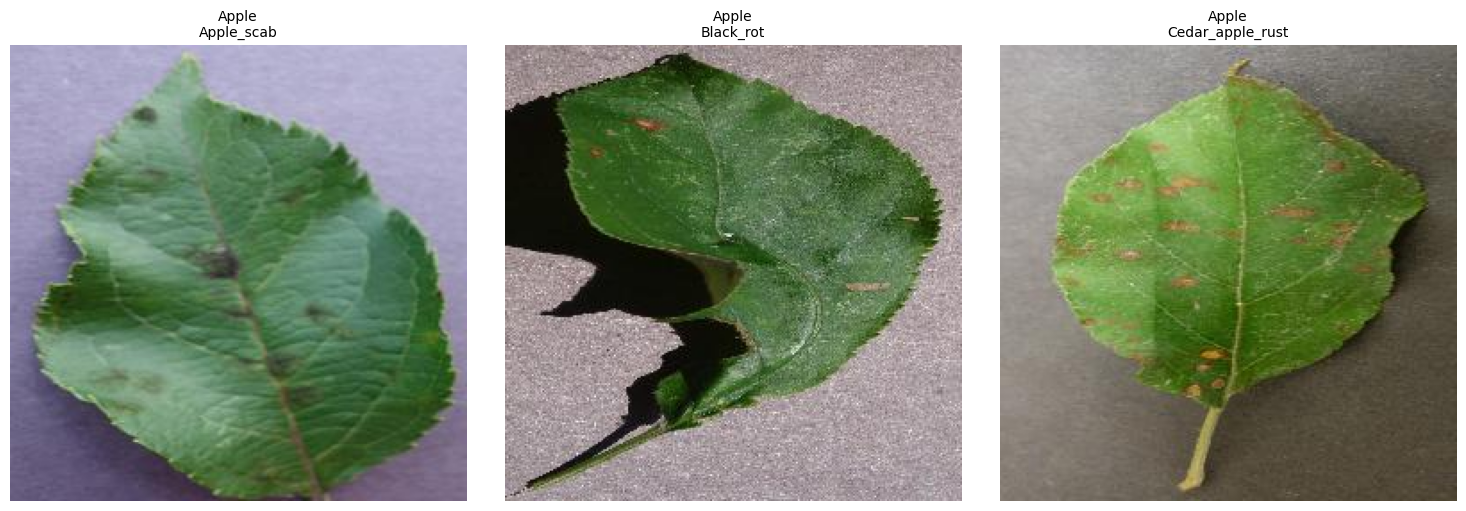

In [2]:
import os
import matplotlib.pyplot as plt
import cv2

# On définit le chemin complet en suivant strictement ta capture d'écran
# Le "r" devant les guillemets permet de gérer les espaces et les backslashs Windows
BASE_DIR = ".." 
RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw", "plantvillage dataset", "color")

# Vérification de sécurité
if not os.path.exists(RAW_DATA_DIR):
    print(f"❌ Erreur : Le dossier est introuvable à l'adresse : {os.path.abspath(RAW_DATA_DIR)}")
else:
    # 1. Lister les catégories
    categories = sorted(os.listdir(RAW_DATA_DIR))
    print(f"✅ Structure validée ! {len(categories)} classes détectées dans le dossier 'color'.")

    # 2. Visualiser un échantillon de 3 plantes différentes
    plt.figure(figsize=(15, 5))

    for i in range(min(3, len(categories))):
        category = categories[i]
        category_path = os.path.join(RAW_DATA_DIR, category)
        
        # Prendre la première image du dossier
        images_in_cat = os.listdir(category_path)
        if len(images_in_cat) > 0:
            img_name = images_in_cat[0]
            img_path = os.path.join(category_path, img_name)
            
            # Charger et convertir
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(1, 3, i+1)
            plt.imshow(img)
            plt.title(category.replace("___", "\n"), fontsize=10)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

C:\Users\HP ELiteBook 840\AppData\Local\Temp\ipykernel_35928\3749059156.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats.sort_values("Nombre_Images", ascending=False),


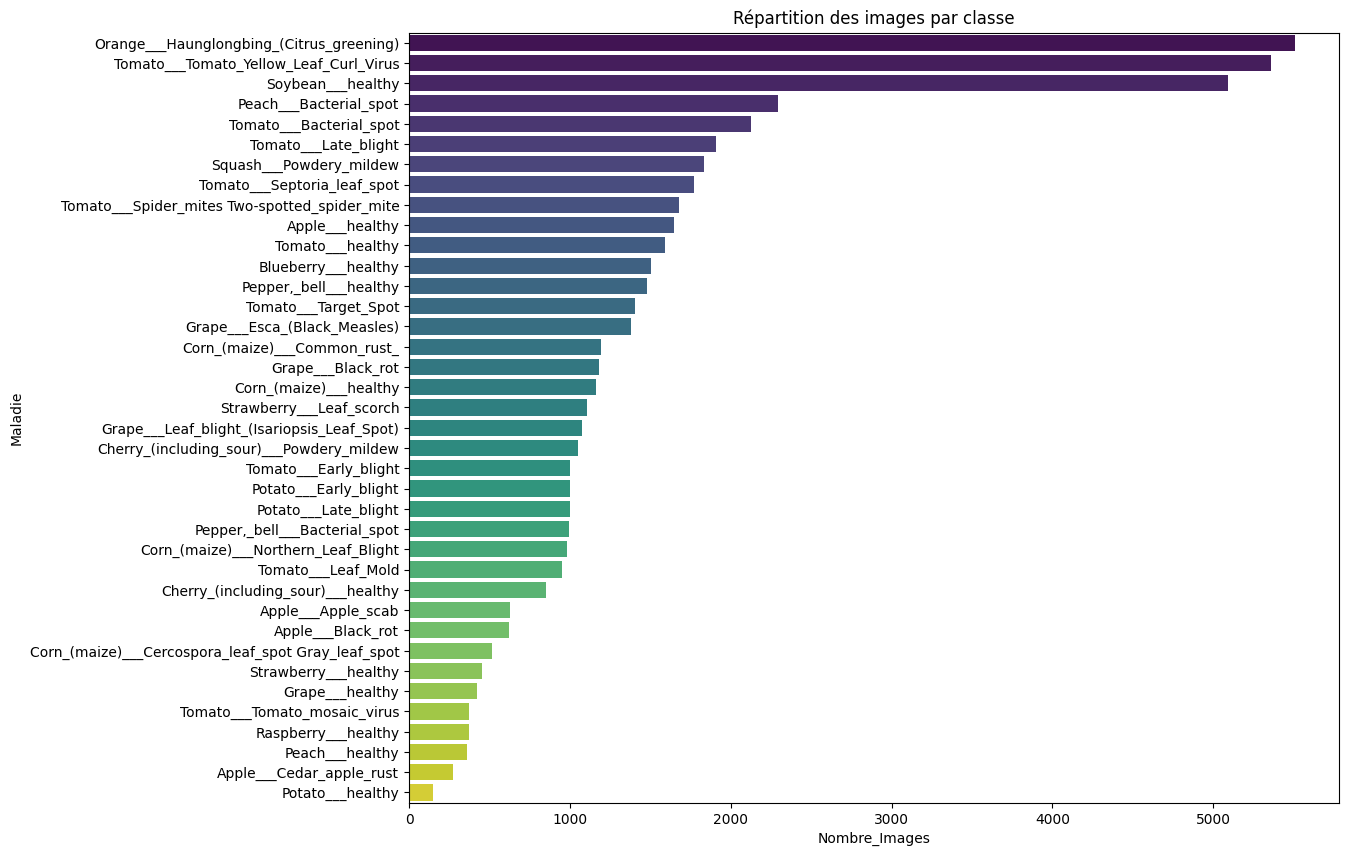

Total d'images : 54305
Moyenne d'images par classe : 1429


In [3]:
import pandas as pd
import seaborn as sns

# 1. Collecter les statistiques
data_stats = []
for category in categories:
    n_images = len(os.listdir(os.path.join(RAW_DATA_DIR, category)))
    data_stats.append({"Maladie": category, "Nombre_Images": n_images})

# 2. Créer un DataFrame pour manipuler les chiffres
df_stats = pd.DataFrame(data_stats)

# 3. Afficher le graphique
plt.figure(figsize=(12, 10))
sns.barplot(data=df_stats.sort_values("Nombre_Images", ascending=False), 
            y="Maladie", x="Nombre_Images", palette="viridis")
plt.title("Répartition des images par classe")
plt.show()

# 4. Afficher quelques chiffres clés
print(f"Total d'images : {df_stats['Nombre_Images'].sum()}")
print(f"Moyenne d'images par classe : {df_stats['Nombre_Images'].mean():.0f}")